In [6]:
import rdkit
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import AllChem
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns
#import molplotly
from CombineMols.CombineMols import CombineMols
import QCflow
from QCflow.load_gaussian import *
from QCflow.energy_calculations import *
from QCflow.torsion_parser import *
from QCflow.find_torsion import *
import re

In [2]:
d_a_df = pd.read_csv('d_a_df.csv')

In [3]:
d_a_df

,Name,SMILES,Donor,Acceptor,D_A EG /eV,A_D EG /eV
0,0,COc1cc2c:C(c3cc(OC(C)=O)cs3):[nH]c2cc1OC,c1cc(OC(C)=O)cs1,c1cc2cc(OC)c(OC)cc2[nH]1,6.452716,4.407624
1,1,COc1cc2c:C(c3cc(NC(C)=O)cs3):[nH]c2cc1OC,c1cc(NC(C)=O)cs1,c1cc2cc(OC)c(OC)cc2[nH]1,6.049390,4.509269
2,2,CNc1csc(C2:cc3cc(OC)c(OC)cc3[nH]:2)c1,c1cc2cc(OC)c(OC)cc2[nH]1,c1cc(NC)cs1,4.925645,5.339527
3,3,COc1csc(C2:cc3cc(OC)c(OC)cc3[nH]:2)c1,c1cc2cc(OC)c(OC)cc2[nH]1,c1cc(OC)cs1,4.721844,5.868828
4,4,COc1cc2c:C(c3cc(C=O)cs3):[nH]c2cc1OC,c1cc(C=O)cs1,c1cc2cc(OC)c(OC)cc2[nH]1,7.186619,3.298856
...,...,...,...,...,...,...
13930,13930,COc1cc2c:C(c3occc3C):n(C)c2cc1OC,c1occc1C,c1cc2cc(OC)c(OC)cc2n1C,6.251815,5.501411
13931,13931,COc1cc2c(ccn2C)c(C=Nc2cc(S(=O)(=O)O)cc3nccnc23...,c1c(OC)c(OC)cc2c1ccn2C,c1cc(S(=O)(=O)O)cc2nccnc12,2.247115,7.576532
13932,13932,CNc1csc(C=Cc2c(OC)c(OC)cc3cc(C(=O)O)[nH]c23)c1,c1cc(NC)cs1,c1c(OC)c(OC)cc2cc(C(=O)O)[nH]c12,4.049719,5.366814
13933,13933,COc1cc2c:C(c3cc(Br)cc4nccnc34):n(C)c2cc1OC,c1cc(Br)cc2nccnc12,c1cc2cc(OC)c(OC)cc2n1C,7.129098,2.603680


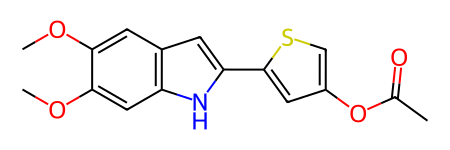

In [88]:
Chem.MolFromSmiles('COc1cc2c:C(c3cc(OC(C)=O)cs3):[nH]c2cc1OC')

In [15]:
all_data = pd.read_csv('ran_all_data.csv')

In [68]:
test_df = all_data[all_data['SMILES'] == 'COc1cc2cc(C=Nc3c(C#N)ccc4nsnc34)[nH]c2cc1OC']
test_df_2 = all_data[all_data['SMILES'] == 'COc1cc2cc(C=Cc3nc(C#N)cc4nonc34)[nH]c2cc1OC']

In [30]:
test_df.update(test_df_2)

In [69]:
test_df

,Name,SMILES,HOMO /eV,LUMO /eV,EG /eV,Planarity,SA Score
3223,5222,COc1cc2cc(C=Nc3c(C#N)ccc4nsnc34)[nH]c2cc1OC,-5.254983,-2.900477,2.354506,1.0,3.075501


In [37]:
test_df = pd.concat([test_df, test_df_2], ignore_index=True)

In [38]:
test_df

,Name,SMILES,HOMO /eV,LUMO /eV,EG /eV,Planarity,SA Score
0,2101,COc1cc2cc(C=Cc3nc(C)cc4nsnc34)n(C)c2cc1OC,-4.859744,-2.490225,2.369519,0.999838,3.052571
1,3408,COc1cc2cc(C=Cc3nc(C#N)cc4nonc34)[nH]c2cc1OC,-5.359747,-3.130061,2.229686,1.000000,3.190326


In [71]:
name_value = all_data.loc[all_data['SMILES'] == v, 'Name'].values
print(name_value)

[2101]


In [84]:
test_smi_dic = open_dictionary('submission_dic/molecules_to_run_1.json')

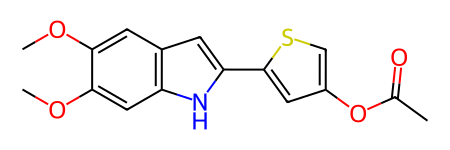

In [89]:
Chem.MolFromSmiles(test_smi_dic['0'])

In [90]:
test_smi_dic['0']

'COc1cc2c:C(c3cc(OC(C)=O)cs3):[nH]c2cc1OC'

In [ ]:
Chem.MolFromSmiles('COc1cc2c:C(c3cc(OC(C)=O)cs3):[nH]c2cc1OC')

In [91]:
test_smi_dic['0'] == 'COc1cc2c:C(c3cc(OC(C)=O)cs3):[nH]c2cc1OC'

True

In [94]:
all_data

,Name,SMILES,HOMO /eV,LUMO /eV,EG /eV,Planarity,SA Score
0,28,COc1cc2c:C(c3c(OC(C)=O)ccc4nsnc34):[nH]c2cc1OC,-4.882895,-2.501781,2.381114,0.990779,2.691665
1,29,COc1cc2c:C(c3c(NC(C)=O)ccc4nsnc34):[nH]c2cc1OC,-5.130549,-2.500508,2.630041,0.911478,2.650507
2,30,CNc1ccc2nsnc2c1C1:cc2cc(OC)c(OC)cc2[nH]:1,-4.815264,-2.240218,2.575046,0.925490,2.718846
3,31,COc1cc2c:C(c3c(OC)ccc4nsnc34):[nH]c2cc1OC,-4.757514,-2.421922,2.335593,0.991889,2.579292
4,32,COc1cc2c:C(c3c(C=O)ccc4nsnc34):[nH]c2cc1OC,-5.440697,-2.917105,2.523592,0.907413,2.768088
...,...,...,...,...,...,...,...
6973,13927,COc1cc2cc(-c3cc(OC):C(c4occ5ncc(O)nc45):s3)n(C...,-4.722566,-1.969009,2.753557,0.840146,3.366356
6974,13929,COc1cc2cc(-c3s:C(c4cc(C=O)cc5c4SCS5):cc3OC)n(C...,-4.893743,-1.932383,2.961360,0.722358,3.411692
6975,13931,COc1cc2c(ccn2C)c(C=Nc2cc(S(=O)(=O)O)cc3nccnc23...,-5.505228,-2.292638,3.212590,0.828431,3.060656
6976,13933,COc1cc2c:C(c3cc(Br)cc4nccnc34):n(C)c2cc1OC,-5.201669,-2.304537,2.897131,0.595196,2.589839


In [93]:
all_data[all_data['SMILES'] == test_smi_dic['0']]

,Name,SMILES,HOMO /eV,LUMO /eV,EG /eV,Planarity,SA Score


In [66]:
all_data.to_csv('ran_all_data.csv', index=False)

In [85]:
empty_df = all_data.iloc[0:0].copy()

In [92]:
for k, v in test_smi_dic.items():
    #canon_smi = Chem.CanonSmiles(v, useChiral=0)
    canon_smi = v
    if len(all_data[all_data['SMILES'] == canon_smi]) > 0:
        ran_before = all_data[all_data['SMILES'] == canon_smi].copy()
        ran_before['Name'] = int(k)
        empty_df = pd.concat([empty_df, ran_before])
        print(k, 'Ran before')
    else:
        print(k, 'run the psi4 calculation')

0 run the psi4 calculation
1 run the psi4 calculation
2 run the psi4 calculation
3 run the psi4 calculation
4 run the psi4 calculation
5 run the psi4 calculation
6 run the psi4 calculation
7 run the psi4 calculation
8 run the psi4 calculation
9 run the psi4 calculation
10 run the psi4 calculation
11 run the psi4 calculation
12 run the psi4 calculation
13 run the psi4 calculation
14 run the psi4 calculation
15 run the psi4 calculation
16 run the psi4 calculation
17 run the psi4 calculation
18 run the psi4 calculation
19 run the psi4 calculation
20 run the psi4 calculation
21 run the psi4 calculation
22 run the psi4 calculation
23 run the psi4 calculation
24 run the psi4 calculation
25 run the psi4 calculation
26 run the psi4 calculation
27 run the psi4 calculation
28 Ran before
29 Ran before
30 Ran before
31 Ran before
32 Ran before
33 Ran before
34 Ran before
35 Ran before
36 Ran before
37 Ran before
38 Ran before
39 Ran before
40 Ran before
41 Ran before
42 Ran before
43 Ran before
44

In [64]:
empty_df

,Name,SMILES,HOMO /eV,LUMO /eV,EG /eV,Planarity,SA Score
2008,1117,COc1cc2cc(C=Cc3nc(C)cc4nsnc34)[nH]c2cc1OC,-4.890198,-2.544420,2.345779,1.000000,3.019386
1771,1160,COc1cc2cc(C=Cc3nccc4nsnc34)[nH]c2cc1OC,-4.923427,-2.591322,2.332105,1.000000,2.953766
1952,1446,COc1cc2cc(C=Cc3nc(C#N)cc4nonc34)[nH]c2cc1OC,-5.359747,-3.130061,2.229686,1.000000,3.190326
2483,1466,COc1cc2cc(C=Cc3cc(C#N)cc4nccnc34)n(C)c2cc1OC,-4.900669,-2.504415,2.396254,0.997873,2.872957
1956,1480,COc1cc2cc(C=Cc3cc(C#N)cc4nsnc34)n(C)c2cc1OC,-4.991153,-2.831333,2.159820,0.999912,3.047407
3223,1700,COc1cc2cc(C=Nc3c(C#N)ccc4nsnc34)[nH]c2cc1OC,-5.254983,-2.900477,2.354506,1.000000,3.075501
1186,1726,COc1cc2cc(C=Cc3cc(C#N)cc4nccnc34)[nH]c2cc1OC,-4.940598,-2.525382,2.415217,0.999986,2.833364
1123,1753,COc1cc2cc(C=Cc3scc4ncc(C#N)nc34)n(C)c2cc1OC,-5.018419,-2.968809,2.049610,0.999937,3.225866
2078,2056,COc1cc2cc(C=Cc3cc(C#N)cc4nonc34)n(C)c2cc1OC,-5.332674,-3.013417,2.319256,0.998875,3.016839
1110,2240,COc1cc2cc(C=Cc3nc(C)cc4nsnc34)n(C)c2cc1OC,-4.859744,-2.490225,2.369519,0.999838,3.052571


In [ ]:
empty_df.loc[empty_df['SMILES'] == v, 'Name'] = int(k)

,Name,SMILES,HOMO /eV,LUMO /eV,EG /eV,Planarity,SA Score
1952,3408,COc1cc2cc(C=Cc3nc(C#N)cc4nonc34)[nH]c2cc1OC,-5.359747,-3.130061,2.229686,1.000000,3.190326
2483,4166,COc1cc2cc(C=Cc3cc(C#N)cc4nccnc34)n(C)c2cc1OC,-4.900669,-2.504415,2.396254,0.997873,2.872957
1956,3412,COc1cc2cc(C=Cc3cc(C#N)cc4nsnc34)n(C)c2cc1OC,-4.991153,-2.831333,2.159820,0.999912,3.047407
3223,5222,COc1cc2cc(C=Nc3c(C#N)ccc4nsnc34)[nH]c2cc1OC,-5.254983,-2.900477,2.354506,1.000000,3.075501
1186,2240,COc1cc2cc(C=Cc3cc(C#N)cc4nccnc34)[nH]c2cc1OC,-4.940598,-2.525382,2.415217,0.999986,2.833364
1123,2118,COc1cc2cc(C=Cc3scc4ncc(C#N)nc34)n(C)c2cc1OC,-5.018419,-2.968809,2.049610,0.999937,3.225866
2078,3587,COc1cc2cc(C=Cc3cc(C#N)cc4nonc34)n(C)c2cc1OC,-5.332674,-3.013417,2.319256,0.998875,3.016839
1110,2101,COc1cc2cc(C=Cc3nc(C)cc4nsnc34)n(C)c2cc1OC,-4.859744,-2.490225,2.369519,0.999838,3.052571


In [67]:
import shutil

In [70]:
test_dic = { '1700': 'COc1cc2cc(C=Nc3c(C#N)ccc4nsnc34)[nH]c2cc1OC'}

In [75]:
name_value = all_data.loc[all_data['SMILES'] == v, 'Name'].values
print(name_value[0])

2101


In [77]:
import os

In [79]:
for k, v in test_smi_dic.items():
    canon_smi = Chem.CanonSmiles(v, useChiral=0)
    if len(all_data[all_data['SMILES'] == canon_smi]) > 0:
        #find
        ran_before = all_data[all_data['SMILES'] == canon_smi].copy()
        #copy
        name_value = all_data.loc[all_data['SMILES'] == canon_smi, 'Name'].values
        #get number
        name_str = str(name_value[0])

        #old data folder
        src_dir = f'/Users/student/data_backup/genetic_algorithm_initial_work/{name_str}'
        #new data folder
        backup_dir = f'/Users/student/GA_codebase/GA_with_data_retrieval/MithrilMolGA/MithrilMolGA/data/{k}'
        if os.path.exists(src_dir):
            shutil.copytree(src_dir, backup_dir)
            print(f'Copied {src_dir} to {backup_dir}')
            for filename in os.listdir(backup_dir):
                if re.match(rf'^{name_str}\D', filename):
                    new_filename = re.sub(rf'^{name_str}', k, filename)
                    src = os.path.join(backup_dir, filename)
                    dst = os.path.join(backup_dir, new_filename)
                    os.rename(src, dst)
                    print(f'Renamed {filename} to {new_filename}')
        else:
            print(f'Source directory {src_dir} does not exist, skipping backup.')


        ran_before['Name'] = int(k)
        empty_df = pd.concat([empty_df, ran_before])
        print(k, 'Ran before')
    else:
        print(k, 'run the psi4 calculation')

Source directory /Users/student/data_backup/genetic_algorithm_initial_work/3484 does not exist, skipping backup.
1117 Ran before
Source directory /Users/student/data_backup/genetic_algorithm_initial_work/3141 does not exist, skipping backup.
1160 Ran before
Source directory /Users/student/data_backup/genetic_algorithm_initial_work/3408 does not exist, skipping backup.
1446 Ran before
Source directory /Users/student/data_backup/genetic_algorithm_initial_work/4166 does not exist, skipping backup.
1466 Ran before
Source directory /Users/student/data_backup/genetic_algorithm_initial_work/3412 does not exist, skipping backup.
1480 Ran before
Copied /Users/student/data_backup/genetic_algorithm_initial_work/5222 to /Users/student/GA_codebase/GA_with_data_retrieval/MithrilMolGA/MithrilMolGA/data/1700
Renamed 5222_sp_a_energy_and_gap.txt to 1700_sp_a_energy_and_gap.txt
Renamed 5222_opt.xyz to 1700_opt.xyz
Renamed 5222_opt_energy_and_gap.txt to 1700_opt_energy_and_gap.txt
Renamed 5222_anion.py t

In [ ]:
/Users/student/data_backup/genetic_algorithm_initial_work/5222

In [ ]:
src_dir = f'/Users/student/data_backup/genetic_algorithm_initial_work/{run_num_str}'
backup_dir = f'/Users/student/GA_codebase/GA_with_data_retrieval/MithrilMolGA/MithrilMolGA/data/{k}'
if os.path.exists(src_dir):
    shutil.copytree(src_dir, backup_dir)
    print(f'Copied {src_dir} to {backup_dir}')
else:
    print(f'Source directory {src_dir} does not exist, skipping backup.')

In [ ]:
import os
import re

old_number = '2101'
new_number = '2240'

for filename in os.listdir(backup_dir):
    if re.match(rf'^{old_number}\D', filename):
        new_filename = re.sub(rf'^{old_number}', new_number, filename)
        src = os.path.join(backup_dir, filename)
        dst = os.path.join(backup_dir, new_filename)
        os.rename(src, dst)
        print(f'Renamed {filename} to {new_filename}')